# Ages from APOKASC and APO-K2

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import ascii

import paths
from utils import fits_to_pandas, binned_medians
from mwm_sample import galactic_to_galactocentric, orbit_dynamics

plt.style.use(paths.styles / 'notebook.mplstyle')

In [19]:
# Base APOKASC-3 catalog
apokasc = fits_to_pandas(paths.data / 'APOGEE' / 'APOKASC_cat_v7.4.0.fits')
apokasc

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/astropy/units/core.py:2085: UnitsWarning: 'Angle[mas]' did not parse as fits unit: At col 0, Unit 'Angle[mas]' not supported by the FITS standard.  If this is meant to be a custom unit, define it with 'u.def_unit'. To have it recognized inside a file reader or other code, enable it with 'u.add_enabled_units'. For details, see https://docs.astropy.org/en/latest/units/combining_and_defining.html
  warnings.warn(msg, UnitsWarning)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/astropy/units/core.py:2085: UnitsWarning: 'Angle[mas]' did not parse as fits unit: At col 0, Unit 'Angle[mas]' not supported by the FITS standard.  If this is meant to be a custom unit, define it with 'u.def_unit'. To have it recognized inside a file reader or other code, enable it with 'u.add_enabled_units'. For details, see https://docs.astropy.org/en/latest/units/combining_and_defining.html
  warnings.warn(msg, UnitsWarning)



,KEPLER_ID,KEPLER_INT,2MASS_ID,LOC_ID,TELESCOPE,FIELD,RA,DEC,RA_PM,DEC_PM,...,OBS_QUART,DELTA_MAGNITUDE_16,PW_BINARY_P,PW_BINARY_E,PW_BINARY_K,CFOP,COLMAN,TARGFLAGS,ASPCAPFLAGS,APOKASC2_NOTE
0,10000151,10000151,2M19051857+4654038,5006,apo25m,K06_078+16,286.327395,46.901066,0.0,0.0,...,011111111111111111,-9999.0,-9999.000000,-9999.000000,-9999.000000,F,F,"APOGEE2_APOKASC,APOGEE2_ANCILLARY,APOGEE2_FAIN...",NaN,-9999
1,10000162,10000162,2M19052050+4655041,5006,apo25m,K06_078+16,286.335457,46.917831,0.0,0.0,...,011111111111111111,-9999.0,-9999.000000,-9999.000000,-9999.000000,T,F,APOGEE2_KOI,NaN,-9999
2,10000198,10000198,2M19052775+4658526,5006,apo25m,K06_078+16,286.365656,46.981289,0.0,0.0,...,011111111111111111,-9999.0,-9999.000000,-9999.000000,-9999.000000,F,F,"APOGEE2_APOKASC,APOGEE2_ANCILLARY,APOGEE2_FAIN...",NaN,-9999
3,10000207,10000207,2M19052985+4654372,4405,apo25m,K06_078+16,286.374415,46.910336,0.0,0.0,...,111111111111111111,-9999.0,-9999.000000,-9999.000000,-9999.000000,F,F,"APOGEE_ANCILLARY,APOGEE_KEPLER_SEISMO",NaN,...
4,10000490,10000490,2M19061343+4657264,5006,apo25m,K06_078+16,286.555994,46.957340,0.0,0.0,...,111111111111111111,-9999.0,-9999.000000,-9999.000000,-9999.000000,T,F,APOGEE2_KOI,"C_M_WARN,N_M_WARN,VSINI_WARN",-9999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24005,9995937,9995937,2M18553632+4659372,5003,apo25m,K03_077+20,283.901366,46.993679,0.0,0.0,...,111111111111111111,-9999.0,-9999.000000,-9999.000000,-9999.000000,F,F,"APOGEE2_APOKASC_DWARF,APOGEE2_APOKASC","VMICRO_WARN,N_M_WARN",-9999
24006,9996021,9996021,2M18554840+4657318,5003,apo25m,K03_077+20,283.951707,46.958843,0.0,0.0,...,111111111111111111,-9999.0,-9999.000000,-9999.000000,-9999.000000,F,F,"APOGEE2_APOKASC_DWARF,APOGEE2_APOKASC","VMICRO_WARN,VSINI_WARN",-9999
24007,9996342,9996342,2M18563273+4658576,5003,apo25m,K03_077+20,284.136391,46.982693,0.0,0.0,...,110000000000000000,-9999.0,-9999.000000,-9999.000000,-9999.000000,F,F,"APOGEE2_APOKASC_GIANT,APOGEE2_APOKASC",NaN,-9999
24008,9996347,9996347,2M18563433+4657134,5003,apo25m,K03_077+20,284.143083,46.953739,0.0,0.0,...,111111111111111111,-9999.0,-9999.000000,-9999.000000,-9999.000000,F,F,"APOGEE2_APOKASC_DWARF,APOGEE2_APOKASC",VMICRO_WARN,-9999


In [20]:
# Base APO-K2 age catalogs
rgb_table = ascii.read(paths.data / 'APOGEE' / 't1_apok2_rgb_ages.txt')
apok2 = rgb_table.to_pandas()
apok2

,EPIC,APOGEE,GaiaEDR3,RAdeg,DEdeg,GLON,GLAT,Rkpc,Zkpc,Teff,...,e_logg-seis,numax,e_numax,deltanu,e_deltanu,Age,e_Age,E_Age,Age-mode,SFW
0,211821580,2M08270102+1737253,662088729307609216,126.7543,17.6237,206.812,28.792,10.252,1.306,4795,...,0.01,34.4,0.9,4.42,0.01,11.3,3.0,4.1,10.8,4.32
1,212434736,2M13572534-1408010,6302108283398593152,209.3556,-14.1336,326.169,45.740,7.504,0.795,4787,...,0.00,116.8,0.7,10.56,0.00,7.3,0.5,0.5,7.2,7.43
2,212333123,2M13400342-1634554,3605202458865639552,205.0143,-16.5821,319.433,44.726,6.713,2.016,4795,...,0.00,87.3,0.7,9.03,0.10,16.8,4.0,5.3,17.5,5.61
3,212173678,2M08253330+2334276,678233202137154304,126.3888,23.5743,200.250,30.532,9.024,0.587,4780,...,0.00,74.9,0.9,7.31,0.03,4.3,0.6,0.7,4.1,6.53
4,213789445,2M19182284-2816172,6759783812391009920,289.5952,-28.2715,9.756,-17.933,6.271,-0.595,4438,...,0.03,14.6,1.0,2.04,0.06,3.0,2.1,6.8,2.7,3.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4656,213763794,2M19172557-2821003,6759691526436811008,289.3566,-28.3501,9.597,-17.767,5.546,-0.829,4710,...,0.01,63.3,1.1,6.82,0.04,10.0,2.1,2.7,9.6,5.63
4657,211844991,2M08255737+1756583,662156589790757504,126.4891,17.9495,206.361,28.678,11.095,1.789,4783,...,0.00,54.9,0.3,5.97,0.08,5.7,1.5,2.0,5.5,3.16
4658,211895016,2M08165721+1839104,657422745555024384,124.2384,18.6529,204.731,26.951,9.24,0.642,4653,...,0.01,45.7,0.6,5.11,0.03,6.7,1.3,1.6,6.8,11.99
4659,201681453,2M11570040+0319481,3893107894972402048,179.2517,3.3300,271.921,62.877,8.136,1.739,4755,...,0.01,58.3,1.1,6.45,0.09,10.2,3.3,4.8,10.0,3.78


In [21]:
# APOGEE DR17
apogee = fits_to_pandas(paths.data / 'APOGEE' / 'allStarLite-dr17-synspec_rev1.fits', hdu=1)
# Drop duplicates
apogee = apogee.sort_values(['APOGEE_ID', 'SNREV'], ascending=True).drop_duplicates(subset='APOGEE_ID', keep='last')
apogee.set_index('APOGEE_ID', drop=True, inplace=True)
# Select stars in either APOKASC or APOK2
kepler_stars = apokasc['2MASS_ID'].to_list() + apok2['APOGEE'].to_list()
apogee = apogee.loc[kepler_stars].copy()
# Calculate galactocentric coordinates based on galactic l, b and Gaia dist
galr, galphi, galz = galactic_to_galactocentric(
    apogee['GLON'], apogee['GLAT'], apogee['GAIAEDR3_R_MED_PHOTOGEO']/1000
)
apogee['GALR'] = galr # kpc
apogee['GALPHI'] = galphi # deg
apogee['GALZ'] = galz # kpc
# Compute orbits
rguide, zmax, ecc, energy, Lz = orbit_dynamics(
    apogee['RA'], apogee['DEC'], apogee['GAIAEDR3_R_MED_PHOTOGEO']/1000,
    apogee['GAIAEDR3_PMRA'], apogee['GAIAEDR3_PMDEC'], apogee['VHELIO_AVG']
)
apogee['GALPY_RGUIDE'] = rguide
apogee['GALPY_ZMAX'] = zmax
apogee['GALPY_ECC'] = ecc
apogee['GALPY_ENERGY'] = energy
apogee['GALPY_LZ'] = Lz
# Calculate abundances
apogee['CE_MG'] = apogee['CE_FE'] - apogee['MG_FE']
apogee['CE_MG_ERR'] = np.sqrt(apogee['CE_FE_ERR']**2 + apogee['MG_FE_ERR']**2)
apogee

,TELESCOPE,FIELD,ALT_ID,RA,DEC,GLON,GLAT,J,J_ERR,H,...,GALR,GALPHI,GALZ,GALPY_RGUIDE,GALPY_ZMAX,GALPY_ECC,GALPY_ENERGY,GALPY_LZ,CE_MG,CE_MG_ERR
APOGEE_ID,,,,,,,,,,,,,,,,,,,,,
2M19051857+4654038,apo25m,K06_078+16,none,286.327395,46.901066,77.367032,17.227543,12.495,0.020,12.014,...,7.924196,166.891106,0.590878,8.687316,0.711634,0.109276,-38300.820312,1897.781401,-0.088905,0.145304
2M19052050+4655041,apo25m,K06_078+16,none,286.335457,46.917831,77.385476,17.228579,13.507,0.024,12.949,...,8.114211,154.928576,1.111442,7.211430,1.227597,0.176901,-44387.249105,1604.035676,-0.096885,0.097650
2M19052775+4658526,apo25m,K06_078+16,none,286.365656,46.981289,77.455199,17.232717,12.204,0.021,11.717,...,7.936801,164.520316,0.692716,6.902782,0.762139,0.185064,-46968.463015,1540.664912,-0.350767,0.116604
2M19052985+4654372,apo25m,K06_078+16,none,286.374415,46.910336,77.388419,17.201075,10.811,0.021,10.261,...,7.942678,171.206524,0.405289,6.671553,0.429293,0.185984,-49052.121428,1492.640537,-0.686733,0.071995
2M19061343+4657264,apo25m,K06_078+16,none,286.555994,46.957340,77.481983,17.103146,10.623,0.021,10.471,...,8.002215,175.271436,0.228348,8.662540,0.275010,0.085643,-39053.945200,1892.953797,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2M19172557-2821003,apo25m,K2_C7_009-18_btx,none,289.356557,-28.350103,9.597081,-17.767318,12.094,0.022,11.541,...,5.826245,176.154780,-0.736076,4.596413,1.777230,0.291434,-59489.193512,1033.441530,-0.375683,0.109969
2M08255737+1756583,apo25m,207+27_btx,none,126.489068,17.949537,206.360581,28.678209,12.636,0.021,12.105,...,10.635601,-173.450449,1.521513,10.544624,1.817100,0.131355,-29391.693131,2252.668167,-0.883573,0.123238
2M08165721+1839104,apo25m,K2_C5_204+27_btx,none,124.238403,18.652899,204.730746,26.951098,10.133,0.021,9.549,...,9.194542,-176.952993,0.617506,8.275269,0.824823,0.218861,-38683.059293,1817.088400,-0.147485,0.057850


In [22]:
apogee.columns.to_list()

['TELESCOPE',
 'FIELD',
 'ALT_ID',
 'RA',
 'DEC',
 'GLON',
 'GLAT',
 'J',
 'J_ERR',
 'H',
 'H_ERR',
 'K',
 'K_ERR',
 'AK_TARG',
 'AK_TARG_METHOD',
 'AK_WISE',
 'SFD_EBV',
 'APOGEE_TARGET1',
 'APOGEE_TARGET2',
 'APOGEE2_TARGET1',
 'APOGEE2_TARGET2',
 'APOGEE2_TARGET3',
 'APOGEE2_TARGET4',
 'TARGFLAGS',
 'SURVEY',
 'PROGRAMNAME',
 'NVISITS',
 'SNR',
 'SNREV',
 'STARFLAG',
 'STARFLAGS',
 'ANDFLAG',
 'ANDFLAGS',
 'VHELIO_AVG',
 'VSCATTER',
 'VERR',
 'RV_TEFF',
 'RV_LOGG',
 'RV_FEH',
 'RV_ALPHA',
 'RV_CARB',
 'RV_CHI2',
 'RV_CCFWHM',
 'RV_AUTOFWHM',
 'RV_FLAG',
 'N_COMPONENTS',
 'MEANFIB',
 'SIGFIB',
 'MIN_H',
 'MAX_H',
 'MIN_JK',
 'MAX_JK',
 'GAIAEDR3_SOURCE_ID',
 'GAIAEDR3_PARALLAX',
 'GAIAEDR3_PARALLAX_ERROR',
 'GAIAEDR3_PMRA',
 'GAIAEDR3_PMRA_ERROR',
 'GAIAEDR3_PMDEC',
 'GAIAEDR3_PMDEC_ERROR',
 'GAIAEDR3_PHOT_G_MEAN_MAG',
 'GAIAEDR3_PHOT_BP_MEAN_MAG',
 'GAIAEDR3_PHOT_RP_MEAN_MAG',
 'GAIAEDR3_DR2_RADIAL_VELOCITY',
 'GAIAEDR3_DR2_RADIAL_VELOCITY_ERROR',
 'GAIAEDR3_R_MED_GEO',
 'GAIAEDR3_R

In [23]:
# Join APOKASC
apokasc3_cols = ['2MASS_ID'] + [c for c in apokasc.columns.to_list() if 'APOKASC3_' in c]
apokasc = apogee.join(apokasc[apokasc3_cols].set_index('2MASS_ID'), on='APOGEE_ID', how='right')
apokasc.replace(-9999, np.nan, inplace=True)
apokasc

,TELESCOPE,FIELD,ALT_ID,RA,DEC,GLON,GLAT,J,J_ERR,H,...,APOKASC3_AGE_RCAGB_PERR,APOKASC3_AGE_RCAGB_MERR,APOKASC3_ALPHA_CAT,APOKASC3_TEFFMOD_JT,APOKASC3_MLMOD_JT,APOKASC3_AGEMOD_JT,APOKASC3_C12MOD_JT,APOKASC3_C13MOD_JT,APOKASC3_N14MOD_JT,APOKASC3_XSURFMOD_JT
APOGEE_ID,,,,,,,,,,,,,,,,,,,,,
2M19051857+4654038,apo25m,K06_078+16,none,286.327395,46.901066,77.367032,17.227543,12.495,0.020,12.014,...,NaN,NaN,Apoor,-99.000000,-99.000000,-99.0000,-99.000000,-99.000000,-99.000000,-99.00000
2M19052050+4655041,apo25m,K06_078+16,none,286.335457,46.917831,77.385476,17.228579,13.507,0.024,12.949,...,1.4128,-1.2206,Apoor,4628.700195,1.929106,9.9850,0.003010,0.000100,0.001705,0.67556
2M19052775+4658526,apo25m,K06_078+16,none,286.365656,46.981289,77.455199,17.232717,12.204,0.021,11.717,...,1.0372,-0.8524,Apoor,4740.100098,1.928836,7.4752,0.001733,0.000059,0.001058,0.69591
2M19052985+4654372,apo25m,K06_078+16,none,286.374415,46.910336,77.388419,17.201075,10.811,0.021,10.261,...,1.2307,-1.0857,Arich,4654.500000,1.821389,9.2563,0.001492,0.000049,0.000836,0.69299
2M19061343+4657264,apo25m,K06_078+16,none,286.555994,46.957340,77.481983,17.103146,10.623,0.021,10.471,...,NaN,NaN,-9999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2M18553632+4659372,apo25m,K03_077+20,none,283.901366,46.993679,76.841189,18.809075,10.412,0.022,10.050,...,NaN,NaN,-9999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2M18554840+4657318,apo25m,K03_077+20,none,283.951707,46.958843,76.818991,18.764898,10.298,0.020,9.904,...,NaN,NaN,-9999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2M18563273+4658576,apo25m,K03_077+20,none,284.136391,46.982693,76.888246,18.654680,10.566,0.021,9.930,...,0.7258,-0.6282,Apoor,4336.500000,1.886996,6.0853,0.003423,0.000123,0.002412,0.66594


In [24]:
apokasc.columns.to_list()

['TELESCOPE',
 'FIELD',
 'ALT_ID',
 'RA',
 'DEC',
 'GLON',
 'GLAT',
 'J',
 'J_ERR',
 'H',
 'H_ERR',
 'K',
 'K_ERR',
 'AK_TARG',
 'AK_TARG_METHOD',
 'AK_WISE',
 'SFD_EBV',
 'APOGEE_TARGET1',
 'APOGEE_TARGET2',
 'APOGEE2_TARGET1',
 'APOGEE2_TARGET2',
 'APOGEE2_TARGET3',
 'APOGEE2_TARGET4',
 'TARGFLAGS',
 'SURVEY',
 'PROGRAMNAME',
 'NVISITS',
 'SNR',
 'SNREV',
 'STARFLAG',
 'STARFLAGS',
 'ANDFLAG',
 'ANDFLAGS',
 'VHELIO_AVG',
 'VSCATTER',
 'VERR',
 'RV_TEFF',
 'RV_LOGG',
 'RV_FEH',
 'RV_ALPHA',
 'RV_CARB',
 'RV_CHI2',
 'RV_CCFWHM',
 'RV_AUTOFWHM',
 'RV_FLAG',
 'N_COMPONENTS',
 'MEANFIB',
 'SIGFIB',
 'MIN_H',
 'MAX_H',
 'MIN_JK',
 'MAX_JK',
 'GAIAEDR3_SOURCE_ID',
 'GAIAEDR3_PARALLAX',
 'GAIAEDR3_PARALLAX_ERROR',
 'GAIAEDR3_PMRA',
 'GAIAEDR3_PMRA_ERROR',
 'GAIAEDR3_PMDEC',
 'GAIAEDR3_PMDEC_ERROR',
 'GAIAEDR3_PHOT_G_MEAN_MAG',
 'GAIAEDR3_PHOT_BP_MEAN_MAG',
 'GAIAEDR3_PHOT_RP_MEAN_MAG',
 'GAIAEDR3_DR2_RADIAL_VELOCITY',
 'GAIAEDR3_DR2_RADIAL_VELOCITY_ERROR',
 'GAIAEDR3_R_MED_GEO',
 'GAIAEDR3_R

In [25]:
apokasc_rgb_gold = apokasc[
    (apokasc['APOKASC3_EVSTATE'] == 'RGB') &
    (apokasc['APOKASC3_CAT_TAB'] == 'Gold')
]
apokasc_rgb_gold

,TELESCOPE,FIELD,ALT_ID,RA,DEC,GLON,GLAT,J,J_ERR,H,...,APOKASC3_AGE_RCAGB_PERR,APOKASC3_AGE_RCAGB_MERR,APOKASC3_ALPHA_CAT,APOKASC3_TEFFMOD_JT,APOKASC3_MLMOD_JT,APOKASC3_AGEMOD_JT,APOKASC3_C12MOD_JT,APOKASC3_C13MOD_JT,APOKASC3_N14MOD_JT,APOKASC3_XSURFMOD_JT
APOGEE_ID,,,,,,,,,,,,,,,,,,,,,
2M19052050+4655041,apo25m,K06_078+16,none,286.335457,46.917831,77.385476,17.228579,13.507,0.024,12.949,...,1.4128,-1.2206,Apoor,4628.700195,1.929106,9.9850,0.003010,0.000100,0.001705,0.67556
2M19052775+4658526,apo25m,K06_078+16,none,286.365656,46.981289,77.455199,17.232717,12.204,0.021,11.717,...,1.0372,-0.8524,Apoor,4740.100098,1.928836,7.4752,0.001733,0.000059,0.001058,0.69591
2M19052985+4654372,apo25m,K06_078+16,none,286.374415,46.910336,77.388419,17.201075,10.811,0.021,10.261,...,1.2307,-1.0857,Arich,4654.500000,1.821389,9.2563,0.001492,0.000049,0.000836,0.69299
2M19062193+4657016,apo25m,K06_078+16,none,286.591376,46.950447,77.484624,17.078158,10.712,0.021,10.247,...,0.8054,-0.6402,Apoor,4843.899902,1.878080,6.2632,0.001331,0.000046,0.000829,0.70370
2M19074937+4656118,apo25m,K06_078+16,none,286.955745,46.936623,77.567921,16.842096,8.395,0.023,7.849,...,0.7302,-0.5663,Arich,4544.899902,1.809936,8.1970,0.000554,0.000018,0.000304,0.71529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2M18525740+4656476,apo25m,K03_077+20,none,283.239202,46.946564,76.632914,19.218478,10.659,0.020,10.076,...,0.5744,-0.4996,Apoor,4443.600098,1.955486,4.8234,0.002207,0.000081,0.001647,0.68686
2M18533924+4654407,apo25m,K03_077+20,none,283.413526,46.911308,76.640002,19.094501,11.510,0.021,10.949,...,1.3142,-1.1513,Arich,4557.399902,1.909363,9.8702,0.001453,0.000047,0.000781,0.69673
2M18534324+4657405,apo25m,K03_077+20,none,283.430207,46.961277,76.693855,19.100576,8.938,0.027,8.409,...,0.8890,-0.7266,Apoor,4492.100098,1.906825,7.3982,0.002774,0.000096,0.001790,0.67800


In [26]:
# Join APO-K2
apok2 = apogee.join(apok2[['APOGEE', 'Age', 'e_Age', 'E_Age']].set_index('APOGEE'), how='right')
apok2

,TELESCOPE,FIELD,ALT_ID,RA,DEC,GLON,GLAT,J,J_ERR,H,...,GALPY_RGUIDE,GALPY_ZMAX,GALPY_ECC,GALPY_ENERGY,GALPY_LZ,CE_MG,CE_MG_ERR,Age,e_Age,E_Age
APOGEE_ID,,,,,,,,,,,,,,,,,,,,,
2M08270102+1737253,apo25m,207+27_btx,none,126.754256,17.623714,206.812378,28.792144,11.471,0.021,10.948,...,10.759108,1.725470,0.096481,-28997.150129,2292.930382,-0.392772,0.070295,11.3,3.0,4.1
2M13572534-1408010,apo25m,K2_C6_327+45_btx,none,209.355614,-14.133616,326.169045,45.739910,10.613,0.025,10.098,...,6.663641,0.856834,0.135172,-48964.154541,1490.988366,-0.510583,0.067974,7.3,0.5,0.5
2M13400342-1634554,apo25m,320+45,none,205.014274,-16.582079,319.432748,44.726273,12.637,0.024,12.056,...,8.450062,4.081055,0.402939,-29596.339625,1851.426696,-0.619213,0.143913,16.8,4.0,5.3
2M08253330+2334276,apo25m,201+30_btx,none,126.388760,23.574337,200.250309,30.531545,10.189,0.021,9.652,...,8.449952,1.380892,0.091359,-38605.087712,1851.404988,-0.120667,0.067120,4.3,0.6,0.7
2M19182284-2816172,apo25m,K2_C7_009-18,none,289.595169,-28.271454,9.755624,-17.933274,9.875,0.023,9.207,...,6.964351,0.823269,0.233246,-45648.383536,1553.370866,-0.203563,0.053438,3.0,2.1,6.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2M19172557-2821003,apo25m,K2_C7_009-18_btx,none,289.356557,-28.350103,9.597081,-17.767318,12.094,0.022,11.541,...,4.596413,1.777230,0.291434,-59489.193512,1033.441530,-0.375683,0.109969,10.0,2.1,2.7
2M08255737+1756583,apo25m,207+27_btx,none,126.489068,17.949537,206.360581,28.678209,12.636,0.021,12.105,...,10.544624,1.817100,0.131355,-29391.693131,2252.668167,-0.883573,0.123238,5.7,1.5,2.0
2M08165721+1839104,apo25m,K2_C5_204+27_btx,none,124.238403,18.652899,204.730746,26.951098,10.133,0.021,9.549,...,8.275269,0.824823,0.218861,-38683.059293,1817.088400,-0.147485,0.057850,6.7,1.3,1.6


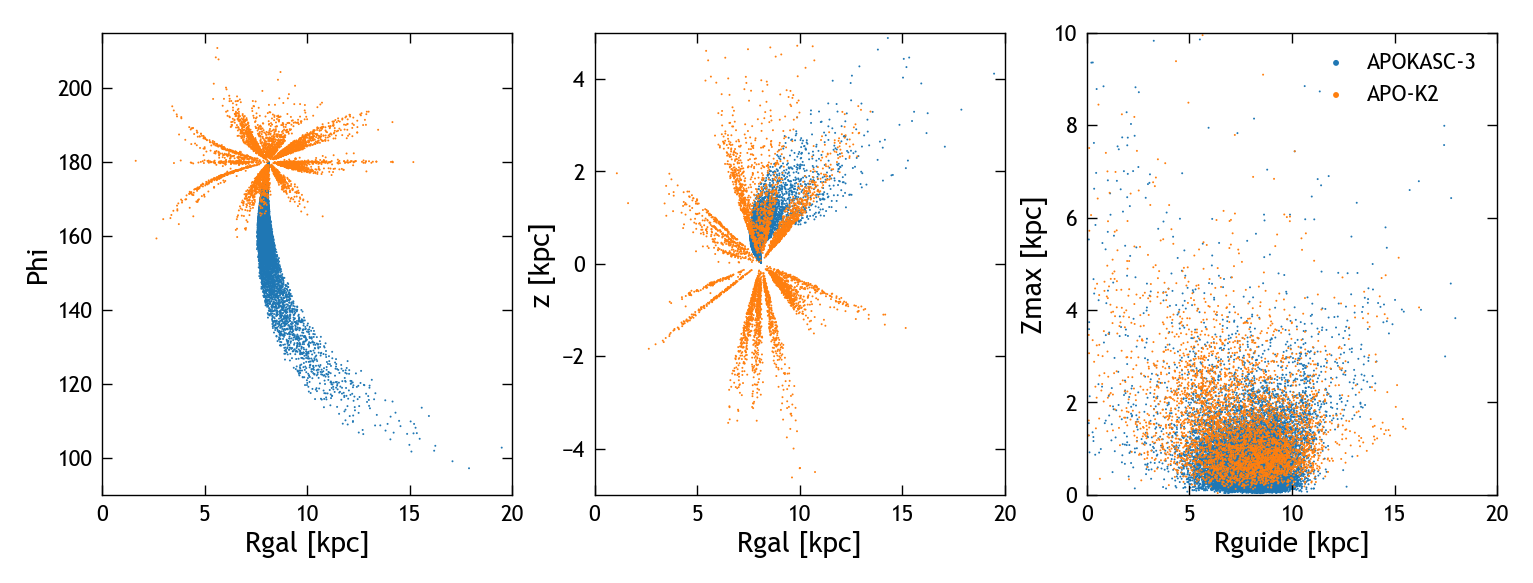

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
kwargs = {'s': 0.5, 'marker': 'o', 'edgecolor': 'none'}
for sample, label in zip([apokasc, apok2], ['APOKASC-3', 'APO-K2']):
    axs[0].scatter(
        sample['GALR'], 
        np.where(sample['GALPHI'] > 0, sample['GALPHI'], 360 + sample['GALPHI']),
        label=label,
        **kwargs
    )
    axs[1].scatter(sample['GALR'], sample['GALZ'], label=label, **kwargs)
    axs[2].scatter(sample['GALPY_RGUIDE'], sample['GALPY_ZMAX'], label=label, **kwargs)
axs[0].set_xlim((0, 20))
axs[0].set_ylim((90, 215))
axs[0].set_xlabel('Rgal [kpc]')
axs[0].set_ylabel('Phi')
axs[1].set_xlim((0, 20))
axs[1].set_ylim((-5, 5))
axs[1].set_xlabel('Rgal [kpc]')
axs[1].set_ylabel('z [kpc]')
axs[2].set_ylim((0, 10))
axs[2].set_xlim((0, 20))
axs[2].set_xlabel('Rguide [kpc]')
axs[2].set_ylabel('Zmax [kpc]')
axs[2].legend(markerscale=3)
plt.show()

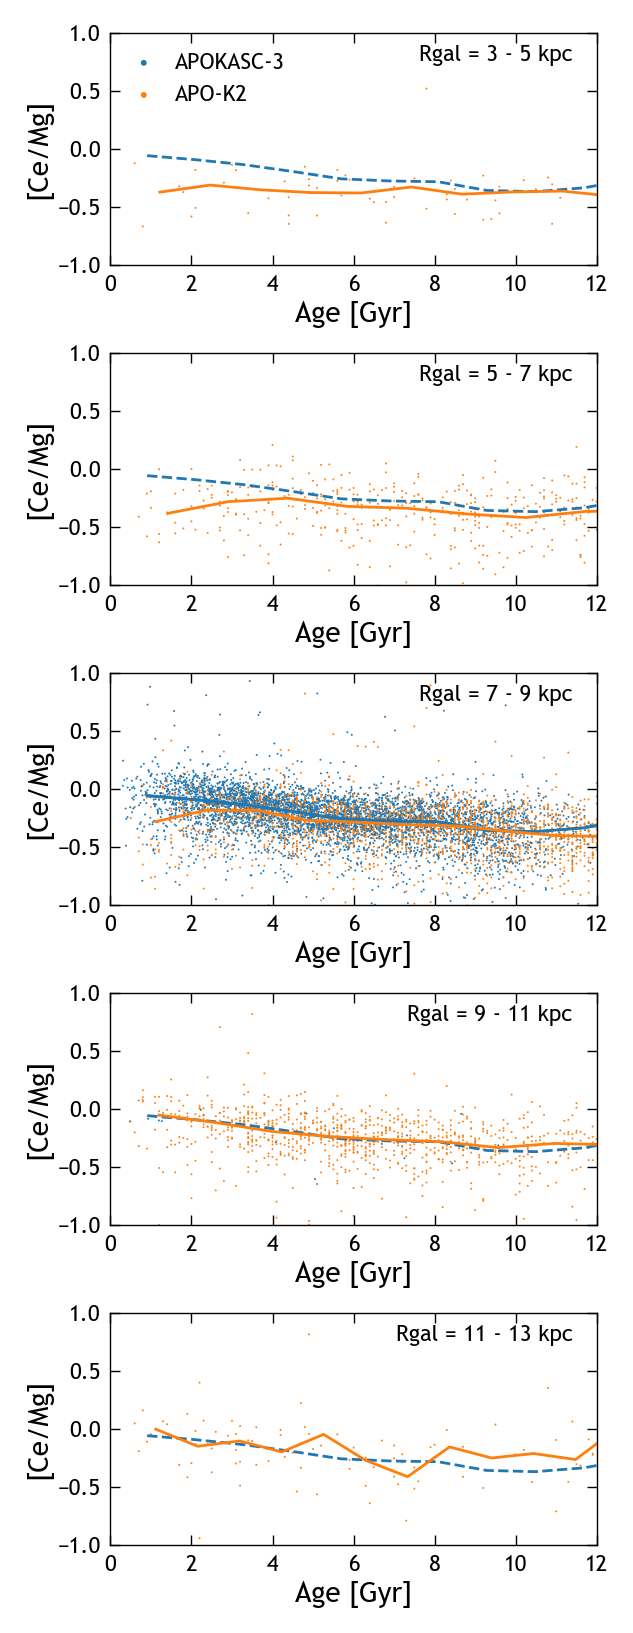

In [37]:
galr_bins = [3, 5, 7, 9, 11, 13]
absz_lim = (0, 3)
kwargs = {'s': 0.5, 'marker': 'o', 'edgecolor': 'none'}

fig, axs = plt.subplots(len(galr_bins)-1, figsize=(3, 8), constrained_layout=True)

local_subset = apokasc_rgb_gold[
    (apokasc_rgb_gold['GALR'] >= 7) &
    (apokasc_rgb_gold['GALR'] < 9) &
    (apokasc_rgb_gold['GALZ'].abs() >= absz_lim[0]) &
    (apokasc_rgb_gold['GALZ'].abs() < absz_lim[1])
]

for i, ax in enumerate(axs):
    galr_lim = (galr_bins[i], galr_bins[i+1])

    apokasc_subset = apokasc_rgb_gold[
        (apokasc_rgb_gold['GALR'] >= galr_lim[0]) &
        (apokasc_rgb_gold['GALR'] < galr_lim[1]) &
        (apokasc_rgb_gold['GALZ'].abs() >= absz_lim[0]) &
        (apokasc_rgb_gold['GALZ'].abs() < absz_lim[1])
    ]
    ax.scatter(apokasc_subset['APOKASC3_AGE_RGB'], apokasc_subset['CE_MG'], label='APOKASC-3', **kwargs)
    # Plot median trends
    ax.plot(*binned_medians(local_subset, 'CE_MG', 'APOKASC3_AGE_RGB', 50), color='C0', linestyle='--')
    if apokasc_subset.shape[0] > 20:
        ax.plot(*binned_medians(apokasc_subset, 'CE_MG', 'APOKASC3_AGE_RGB', 50), color='C0', linestyle='-')

    apok2_subset = apok2[
        (apok2['GALR'] >= galr_lim[0]) &
        (apok2['GALR'] < galr_lim[1]) &
        (apok2['GALZ'].abs() >= absz_lim[0]) &
        (apok2['GALZ'].abs() < absz_lim[1])
    ]
    ax.scatter(apok2_subset['Age'], apok2_subset['CE_MG'], label='APO-K2', **kwargs)
    if apok2_subset.shape[0] > 20:
        ax.plot(*binned_medians(apok2_subset, 'CE_MG', 'Age', 50), color='C1', linestyle='-')

    ax.set_xlim((0, 12))
    ax.set_ylim((-1, 1))
    ax.set_xlabel('Age [Gyr]')
    ax.set_ylabel('[Ce/Mg]')
    ax.text(0.95, 0.95, 'Rgal = %s - %s kpc' % galr_lim,
            transform=ax.transAxes, ha='right', va='top')

axs[0].legend(markerscale=3, loc='upper left')
plt.show()

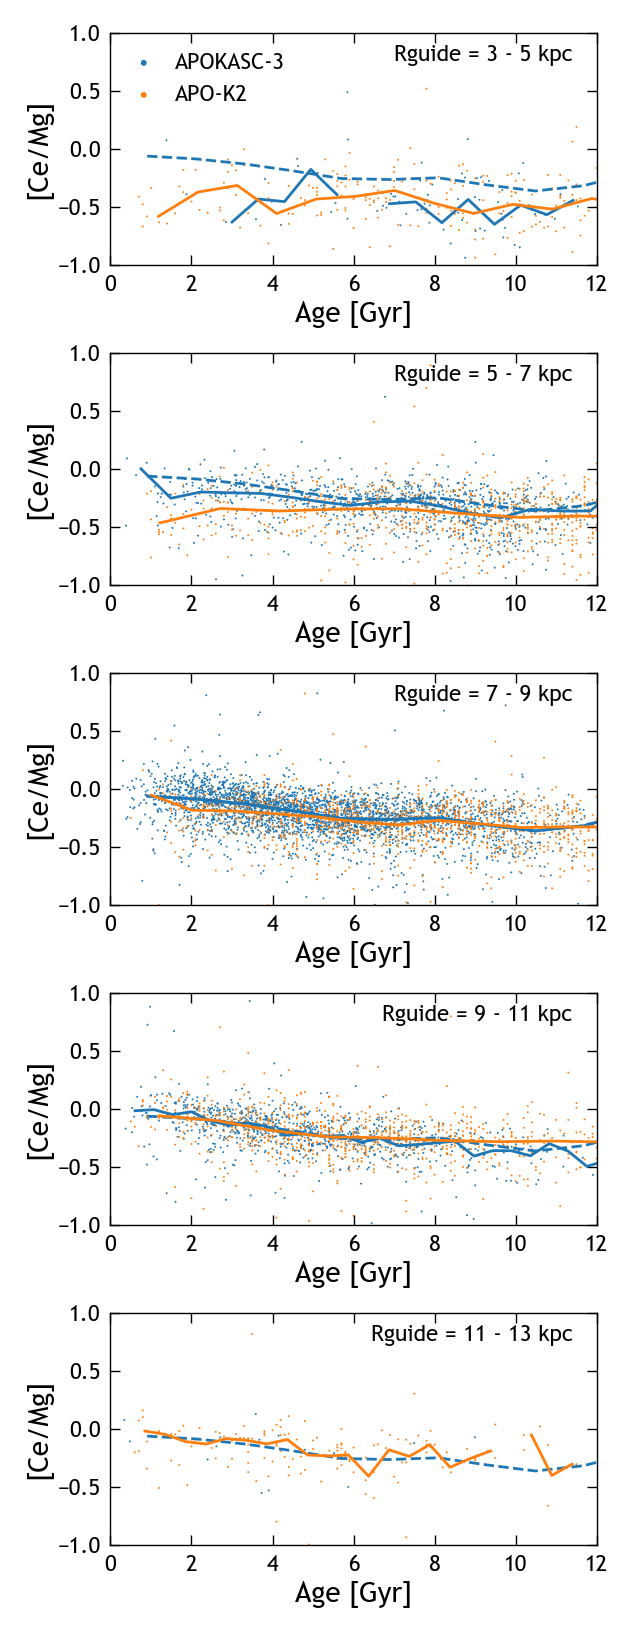

In [38]:
galr_bins = [3, 5, 7, 9, 11, 13]
absz_lim = (0, 3)
kwargs = {'s': 0.5, 'marker': 'o', 'edgecolor': 'none'}

fig, axs = plt.subplots(len(galr_bins)-1, figsize=(3, 8), constrained_layout=True)

local_subset = apokasc_rgb_gold[
    (apokasc_rgb_gold['GALPY_RGUIDE'] >= 7) &
    (apokasc_rgb_gold['GALPY_RGUIDE'] < 9) &
    (apokasc_rgb_gold['GALPY_ZMAX'].abs() >= absz_lim[0]) &
    (apokasc_rgb_gold['GALPY_ZMAX'].abs() < absz_lim[1])
]

for i, ax in enumerate(axs):
    galr_lim = (galr_bins[i], galr_bins[i+1])

    apokasc_subset = apokasc_rgb_gold[
        (apokasc_rgb_gold['GALPY_RGUIDE'] >= galr_lim[0]) &
        (apokasc_rgb_gold['GALPY_RGUIDE'] < galr_lim[1]) &
        (apokasc_rgb_gold['GALPY_ZMAX'].abs() >= absz_lim[0]) &
        (apokasc_rgb_gold['GALPY_ZMAX'].abs() < absz_lim[1])
    ]
    ax.scatter(apokasc_subset['APOKASC3_AGE_RGB'], apokasc_subset['CE_MG'], label='APOKASC-3', **kwargs)
    # Plot median trends
    ax.plot(*binned_medians(local_subset, 'CE_MG', 'APOKASC3_AGE_RGB', 50), color='C0', linestyle='--')
    if apokasc_subset.shape[0] > 20:
        ax.plot(*binned_medians(apokasc_subset, 'CE_MG', 'APOKASC3_AGE_RGB', 50), color='C0', linestyle='-')

    apok2_subset = apok2[
        (apok2['GALPY_RGUIDE'] >= galr_lim[0]) &
        (apok2['GALPY_RGUIDE'] < galr_lim[1]) &
        (apok2['GALPY_ZMAX'].abs() >= absz_lim[0]) &
        (apok2['GALPY_ZMAX'].abs() < absz_lim[1])
    ]
    ax.scatter(apok2_subset['Age'], apok2_subset['CE_MG'], label='APO-K2', **kwargs)
    if apok2_subset.shape[0] > 20:
        ax.plot(*binned_medians(apok2_subset, 'CE_MG', 'Age', 50), color='C1', linestyle='-')

    ax.set_xlim((0, 12))
    ax.set_ylim((-1, 1))
    ax.set_xlabel('Age [Gyr]')
    ax.set_ylabel('[Ce/Mg]')
    ax.text(0.95, 0.95, 'Rguide = %s - %s kpc' % galr_lim,
            transform=ax.transAxes, ha='right', va='top')

axs[0].legend(markerscale=3, loc='upper left')
plt.show()